In [79]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from dotenv import load_dotenv

load_dotenv()

True

In [80]:
sub_llm = ChatGroq(model="openai/gpt-oss-20b", temperature=0.4)

In [81]:
class sub_state(TypedDict):
    input_text: str
    translated_text: str

In [82]:
def translated_text(state: sub_state):
    prompt = f"""
    
    You are a good hindi translated agent,
    you job is to translate the given text into hindi
    
    text :
    {state['input_text']}
    
    """
    translated_text = sub_llm.invoke(prompt)
    return {'translated_text': translated_text.content}

In [83]:
# building the subgraph
subgraph = StateGraph(sub_state)

# adding the graph nodes
subgraph.add_node("translate", translated_text)
subgraph.add_edge(START, "translate")
subgraph.add_edge("translate", END)

subgraph_node = subgraph.compile()

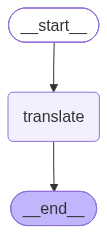

In [86]:
from IPython.display import Image
Image(subgraph_node.get_graph().draw_mermaid_png())

In [87]:
# parent graph state
class parent_state(TypedDict):
    
    question: str
    answer_eng: str
    answer_hin: str

In [88]:
parent_llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.3)

In [89]:
def generate(state: parent_state):
    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {"answer_eng": answer}

In [90]:
def generate_translation_hin(state: parent_state):
    result = subgraph_node.invoke({"input_text": state['answer_eng']})
    return {"answer_hin": result['translated_text']}

In [91]:
#building the parent graph
parent_graph = StateGraph(parent_state)

# graph
parent_graph.add_node("generate", generate)
parent_graph.add_node("generate_translation_hin", generate_translation_hin)

parent_graph.add_edge(START, "generate")
parent_graph.add_edge("generate", "generate_translation_hin")
parent_graph.add_edge("generate_translation_hin", END)

parentG=parent_graph.compile()

In [92]:
response = parentG.invoke({"question": "write 10 lines about ancient egypt"})

In [93]:
response

{'question': 'write 10 lines about ancient egypt',
 'answer_eng': '1. Ancient Egypt flourished along the fertile banks of the Nile River for over three millennia, from around 3100\u202fBC to 30\u202fBC.  \n2. Its civilization is famed for monumental architecture, most famously the pyramids of Giza, built as tombs for pharaohs.  \n3. The pharaoh was considered both a divine ruler and a living god, embodying the unity of state and religion.  \n4. Hieroglyphic writing, a system of pictorial symbols, recorded everything from royal decrees to everyday transactions.  \n5. The Egyptians believed in an elaborate afterlife, prompting elaborate burial practices and the mummification of bodies.  \n6. Their pantheon included gods such as Ra the sun‑disk, Osiris the lord of the dead, and Isis the protective mother goddess.  \n7. Agricultural prosperity relied on the annual inundation of the Nile, which deposited rich silt onto the farmlands.  \n8. Advances in mathematics and engineering enabled pre

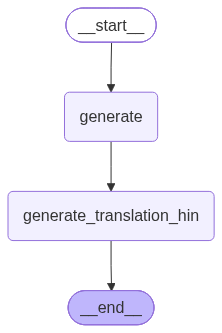

In [94]:
from IPython.display import Image
Image(parentG.get_graph().draw_mermaid_png())